### QUEST 01 — From SLR to MLR (Extending the Model)
#### Q1. SLR Recap — Write the SLR Equation

**Equation**

y^=β0+β1x

Definitions
| Symbol | Meaning              |
| ------ | -------------------- |
| ŷ      | Predicted value of y |
| β₀     | Intercept            |
| β₁     | Slope coefficient    |
| x      | Independent variable |


#### Q2. MLR Model — Multiple Linear Regression
**Equation**

y^i=β0+β1xi1+β2xi2+⋯+βkxik+εi

Definitions

| Symbol    | Meaning                           |
| --------- | --------------------------------- |
| ŷᵢ        | Predicted value for observation i |
| β₀        | Intercept                         |
| β₁...βₖ   | Regression coefficients           |
| xᵢ₁...xᵢₖ | Predictor values                  |
| k         | Number of predictors              |
| i         | Observation number                |
| εᵢ        | Random error term                 |


#### Q3. Why Multiple Predictors?
**House Price Example**

Using only:
x₁ = Area

is not enough.

Additional Features

| Feature                 | Why It Helps                    |
| ----------------------- | ------------------------------- |
| x₂ = Location           | Prime locations cost more       |
| x₃ = Number of Bedrooms | Larger families need more rooms |
| x₄ = Property Age       | Newer homes usually sell higher |
| x₅ = Parking Spaces     | Adds convenience and value      |


#### Q4. Partial Slope Interpretation
**Model**

Salary=5000+800(Experience)+300(Certifications)

**Interpretation of β₁ = 800**

Holding all other variables constant,
each additional year of experience increases expected salary by ₹800.


#### Q5. Difference Between SLR and MLR R²
**SLR**
R² measures variance explained by one predictor.

**MLR**
R² measures variance explained by multiple predictors.

**Problem**
R² always increases when predictors are added, even if those predictors are useless.

**Metric That Fixes This**

✅ Adjusted R²

Formula:

Adjusted R2=1−(1−R2)(n−1)/n−k−1
Adjusted R² penalizes unnecessary predictors.


#### Q6. Assumptions of Multiple Linear Regression

MLR inherits the five assumptions of SLR and adds one more.

| No | Assumption                   |
| -- | ---------------------------- |
| 1  | Linearity                    |
| 2  | Independence of Errors       |
| 3  | Homoscedasticity             |
| 4  | Normality of Residuals       |
| 5  | No Multicollinearity         |
| 6  | No Perfect Multicollinearity |




In [5]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

In [3]:
data = {
    'Area':[1000,1200,1500,1800,2000],
    'Bedrooms':[2,2,3,3,4],
    'Age':[10,8,6,5,3],
    'Price':[30,35,45,50,60]
}

df = pd.DataFrame(data)

X = df[['Area','Bedrooms','Age']]
y = df['Price']

model = LinearRegression()

model.fit(X,y)

print("Intercept (β0):", model.intercept_)

print("\nCoefficients")

for feature, coef in zip(X.columns, model.coef_):
    print(feature, ":", coef)

r2 = model.score(X,y)

print("\nR² Score:", round(r2,4))

Intercept (β0): 22.045454545414344

Coefficients
Area : 0.011363636363663164
Bedrooms : 4.696969696969694
Age : -1.2878787878787863

R² Score: 0.9993


In [4]:
new_house = [[1700,3,4]]

predicted_price = model.predict(new_house)

print("Predicted Price:", predicted_price[0])

Predicted Price: 50.303030303035655


C:\Users\Disha lukhi\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### QUEST 02 — The Design Matrix (Building X)
#### Q1. Dataset

| Observation | x₁ | x₂ | y  |
| ----------- | -- | -- | -- |
| 1           | 2  | 3  | 14 |
| 2           | 4  | 1  | 16 |
| 3           | 6  | 5  | 26 |


Number of observations:
- n=3

Number of predictors:
- k=2

#### Q2. Write the Design Matrix X
In Multiple Linear Regression, the Design Matrix X has dimensions:

- n×(k+1)

since:
n=3,k=2
X=(3×3)

The first column contains all 1s for the intercept term β0.

Therefore,

X= 1 2 3
   1 4 1
   1 6 5

Explanation
- Column 1 → Intercept column
- Column 2 → Feature x1
- Column 3 → Feature x2


#### Q3. Write the Response Vector y

The response vector contains all target values.

y= 14
   16
   26

Dimensions:

(3×1)
	​

#### Q4. Write the Coefficient Vector β

The coefficient vector contains all model parameters.

β=β0
  β1
  β2
	
Dimensions:
              (3×1)

Where:
- β0= Intercept
- β1= Coefficient for x1
- β2= Coefficient for x2

#### Q5. Matrix Model Equation
The Multiple Linear Regression model in matrix form is:

y=Xβ+ε

Substituting the matrices:

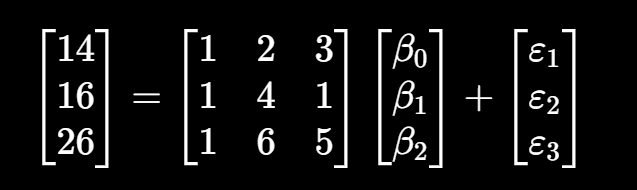


#### Dimension Verification

**Response vector:**

(3×1)

**Design Matrix:**

(3×3)

**Coefficient Vector:**

(3×1)

**Multiplication:**

(3×3)(3×1)=(3×1)

**Adding residual vector:**

(3×1)+(3×1)=(3×1)


Q6. Why a Column of 1s?

The intercept β
0
	​

 is a constant value that affects every observation equally.

Without the column of 1s:

X= 2 3 
   4 1
   6 5
	​


the matrix multiplication would only produce:

β1x1+β2x2​


and the intercept term would be missing.

Adding a column of 1s gives:

1×β0
	​
for every row.

Thus the model becomes:
y^=β0+β1x1+β2x2
	​


which correctly includes the intercept.


In [6]:
X = np.array([
    [1, 2, 3],
    [1, 4, 1],
    [1, 6, 5]
])

# Response Vector
y = np.array([
    [14],
    [16],
    [26]
])

print("Design Matrix X:")
print(X)

print("\nResponse Vector y:")
print(y)

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

# Example coefficient vector
beta = np.array([
    [1],
    [2],
    [3]
])

print("\nCoefficient Vector β:")
print(beta)

print("\nShape of β:", beta.shape)

# Predicted values
y_hat = X @ beta

print("\nPredicted Values:")
print(y_hat)

Design Matrix X:
[[1 2 3]
 [1 4 1]
 [1 6 5]]

Response Vector y:
[[14]
 [16]
 [26]]

Shape of X: (3, 3)
Shape of y: (3, 1)

Coefficient Vector β:
[[1]
 [2]
 [3]]

Shape of β: (3, 1)

Predicted Values:
[[14]
 [12]
 [28]]


### QUEST 03 — Normal Equations in Matrix Form (Notebook Style)

### Q1. Cost Function in Matrix Form

The Multiple Linear Regression (MLR) cost function is:

L(β)=(y−Xβ)T(y−Xβ)

Where:

- y = response vector
- X = design matrix
- β = coefficient vector

This expression measures the total squared prediction error.

Since:

y^=Xβ

then

L(β)=n∑i=1(yi−y^i)2

Therefore:

L(β)=SSE

where SSE = Sum of Squared Errors.